# Polypharmacy Drug-Drug Interaction (DDI) Prediction System

## Giriş & Amaç

Bu projenin amacı, **TWOSIDES** veri setini kullanarak farklı ilaç çiftlerinin bir arada kullanıldığında oluşturabileceği olası yan etkileri **Polifarmasi İlaç-İlaç Etkileşimleri (Polypharmacy Drug-Drug Interactions)** makine öğrenmesi modelleriyle tahmin etmektir.

Biyoinformatik ve sağlık sektöründe kritik bir öneme sahip olan bu problemi çözmek adına, ilaçların kimyasal yapılarını temsil eden **SMILES** verileri ve moleküler özellikler üzerinde çalışılmıştır. Proje kapsamında;
* Veri setinin devasa boyutu (~4.6 milyon satır) nedeniyle, sınıf dengesi korunarak **stratejik alt örnekleme (downsampling)** uygulanmış,
* Keşifsel Veri Analizi (EDA) ile veri yapısı incelenmiş,
* Geliştirilen makine öğrenmesi modelleri (XGBoost, Random Forest vb.) ile yüksek doğruluklu tahminleme hedeflenmiştir.

Geliştirilen bu model, projenin sonraki aşamasında bir **Streamlit** arayüzü ile entegre edilerek kullanıcı dostu bir web uygulamasına dönüştürülecektir.

## Sistem Mimarisi, Sınırlamalar ve Uyarılar

* **Çoklu İlaç Girişi ve İkili (Pairwise) Kombinasyon Mantığı:** Geliştirilen sistem, kullanıcı arayüzünde 10 adede kadar ilaç girişini desteklemektedir. Ancak model, girilen tüm ilaçları kendi içinde **ikili kombinasyonlara (çiftlere)** ayırarak analiz eder. Sistem, bu ikili çiftlerin her biri için ayrı ayrı etkileşim tahmini yürüterek geniş kapsamlı bir kombinasyon raporu sunar.
  * *Önemli Kısıtlama:* Model, yüksek dereceli kombinasyonların (3'lü, 4'lü veya daha fazla ilacın aynı anda alınmasının) yarattığı sinerjik etkileri hesaplayamaz. Örneğin; sisteme girilen 3 ilacın kendi aralarındaki tüm ikili kombinasyonları (A-B, A-C, B-C) güvenli çıkabilir; fakat bu 3 ilaç aynı anda vücuda alındığında tamamen farklı ve öngörülemeyen bir yan etki tetiklenebilir. Model, veri setinin yapısı gereği bu tarz kolektif etkileşimleri tahmin etme yeteneğine sahip değildir.

* Bu proje tamamen akademik ve araştırma odaklı bir makine öğrenmesi çalışmasıdır. Model tarafından üretilen sonuçlar kesin bir tıbbi kanıt veya klinik olarak onaylanmış bir teşhis/reçete niteliği taşımaz; gerçek hayatta bir **tıbbi tavsiye olarak değerlendirilmemelidir**.

## Veri Çekme ve Kütüphaneler

In [ ]:
!pip install PyTDC

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [3]:
from tdc.multi_pred import DDI
data = DDI(name = 'TWOSIDES')
df_raw = data.get_data()
print("Orijinal boyut:", df_raw.shape)
df = df_raw.sample(n=200000, random_state=42).reset_index(drop=True)
print("Örneklenmiş boyut:", df.shape)

Downloading...
100%|██████████| 677M/677M [00:20<00:00, 33.1MiB/s]
Loading...
Done!


Orijinal boyut: (4649441, 5)
Örneklenmiş boyut: (200000, 5)


In [4]:
del df_raw
del data
import gc
gc.collect()

120

TWOSIDES veri seti 4,6 milyon ilaç çifti kaydı içermektedir. RAM limiti nedeniyle, sınıf dengesi korunarak rastgele bir alt örneklem (N=200.000) seçilmiş ve tüm modelleme bu örneklem üzerinde gerçekleştirilmiştir.

## Keşifsel Veri Analizi (EDA)

In [5]:
df.head(3)

,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,CID000003121,CCCC(CCC)C(=O)O,CID000003640,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,267
1,CID000002250,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,CID000005002,C1CN(CCN1CCOCCO)C2=NC3=CC=CC=C3SC4=CC=CC=C42,619
2,CID000000853,C1=C(C=C(C(=C1I)OC2=CC(=C(C(=C2)I)O)I)I)CC(C(=...,CID000004168,CCN(CC)CCNC(=O)C1=CC(=C(C=C1OC)N)Cl,1309


In [6]:
all_drugs = pd.concat([df["Drug1_ID"], df["Drug2_ID"]])
total_unique_drugs = all_drugs.nunique()

print(f"Toplam Etkileşim Sayısı: {df.shape[0]}")
print(f"Sistemdeki TOPLAM Gerçek Benzersiz İlaç Sayısı: {total_unique_drugs}")

Toplam Etkileşim Sayısı: 200000
Sistemdeki TOPLAM Gerçek Benzersiz İlaç Sayısı: 642


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Drug1_ID  200000 non-null  object
 1   Drug1     200000 non-null  object
 2   Drug2_ID  200000 non-null  object
 3   Drug2     200000 non-null  object
 4   Y         200000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 7.6+ MB


,0
Drug1_ID,0
Drug1,0
Drug2_ID,0
Drug2,0
Y,0


Veri setinde boş değer bulunmamaktadır. Object tipindeki Drug1_ID, Drug1, Drug2_ID, Drug2 sütunları ilaçların ID'sini ve SMILES kodunu belirtir. SMILES (Simplified Molecular Input Line Entry System) kimyasal moleküllerin yapısını bilgisayarların okuyabileceği şekilde tek bir satır olarak ifade etmeye yarayan evrensel bir standarttır.

Integer tipindeki Y sütunu ise Drug1 ve Drug2 ilaçları arasındaki etkileşim türünü numaralandırarak gösterir.


In [8]:
df["Y"].value_counts().head(20)

,count
Y,
464,1282
37,1207
258,1104
600,1088
238,1035
692,1030
74,1017
315,1012
648,987


In [9]:
df_most = df["Y"].value_counts().head(20).reset_index()
df_most.columns = ["Y", "count"]

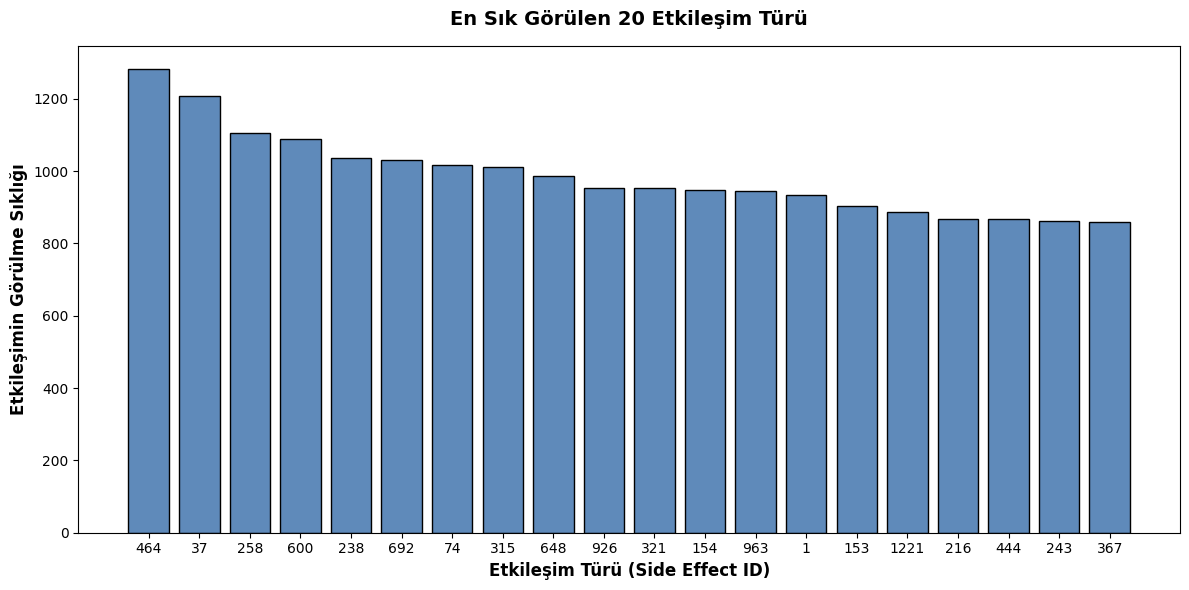

In [10]:
interaction_type = df_most["Y"].astype(str)
count = df_most["count"]

plt.figure(figsize=(12, 6))
plt.bar(interaction_type, count, color="#5f8aba", edgecolor="black")
plt.xlabel("Etkileşim Türü (Side Effect ID)" , fontsize=12, fontweight="bold")
plt.ylabel("Etkileşimin Görülme Sıklığı" , fontsize=12, fontweight="bold")
plt.title("En Sık Görülen 20 Etkileşim Türü" , fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

In [11]:
unique_pairs= df[["Drug1_ID" , "Drug2_ID"]].drop_duplicates()
connections = pd.concat([
    unique_pairs.rename(columns={"Drug1_ID": "DrugID", "Drug2_ID": "Neighbor"}),
    unique_pairs.rename(columns={"Drug2_ID": "DrugID", "Drug1_ID": "Neighbor"})
])
connections

,DrugID,Neighbor
0,CID000003121,CID000003640
1,CID000002250,CID000005002
2,CID000000853,CID000004168
3,CID000003339,CID000003348
4,CID000001302,CID000003121
...,...,...
199927,CID000054808,CID000004583
199939,CID000148192,CID000005514
199950,CID000060843,CID000003350
199958,CID000003467,CID000003043


In [12]:
drug_degrees = connections.groupby("DrugID")["Neighbor"].nunique().reset_index(name="Degree")
drug_degrees.head(5)

,DrugID,Degree
0,CID000000085,36
1,CID000000119,35
2,CID000000143,218
3,CID000000159,69
4,CID000000191,61


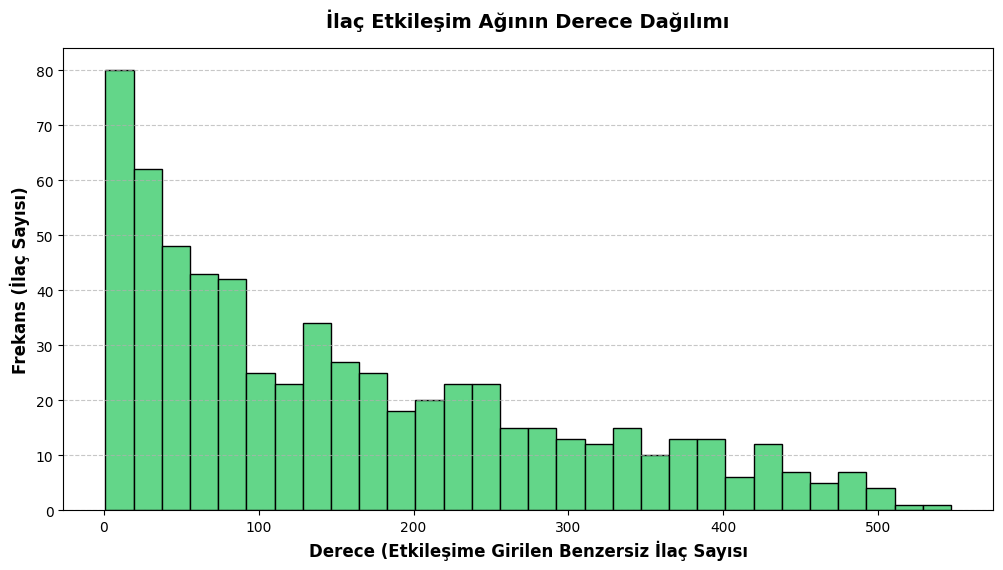

In [13]:
data = drug_degrees["Degree"]
plt.figure(figsize=(12, 6))
plt.hist(data, bins=30, color="#63d689", edgecolor="black")
plt.title("İlaç Etkileşim Ağının Derece Dağılımı", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Derece (Etkileşime Girilen Benzersiz İlaç Sayısı" , fontsize=12, fontweight="bold")
plt.ylabel("Frekans (İlaç Sayısı)" , fontsize=12, fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
from rdkit import Chem
unique_smiles = set(df["Drug1"].unique()) | set(df["Drug2"].unique())

valid_smiles_set = {
    s for s in unique_smiles
    if isinstance(s, str) and Chem.MolFromSmiles(s) is not None
}

df_clean = df[df["Drug1"].isin(valid_smiles_set) & df["Drug2"].isin(valid_smiles_set)]

print(f"Silinen hatalı satır sayısı: {len(df) - len(df_clean)}")

Silinen hatalı satır sayısı: 0


## EDA Bulguları
* Küçültülmüş veri setindeki toplam benzersiz ilaç sayısı 642, toplam etkileşim sayısı ise 200 000 'dir.

* Boş veri ve tanımsız ilaç bulunmamaktadır. Veri son derece kalitelidir.

* En sık görülen ilk 20 etkileşim türünün frekans dağılımı incelendiğinde, sınıflar arasında keskin bir uçurum olmadığı ve frekansların yumuşak bir geçiş gösterdiği gözlemlenmiştir. Bu durum, model eğitilirken en sık görülen bu sınıflar özelinde ciddi bir sınıf dengesizliği (class imbalance) yaşanmayacağını ve modelin bu sınıfları öğrenirken yanlılık (bias) geliştirmesinin minimumda kalacağını göstermektedir.

* İlaç etkileşim ağının derece dağılımı grafiği, veri setinin ölçeksiz ağ (scale-free network) yapısına sahip olduğunu göstermektedir. Az sayıda muhtemelen popüler olan ilaçlar çok yüksek sayıda (500+) etkileşime sahipken, ilaçların büyük bir çoğunluğu daha az etkileşime sahiptir. Bu durum, girdi bazında bir dengesizlik yaratmaktadır.Model, çok sık etkileşime giren (yüksek dereceli) ilaçların kimyasal yapılarını çok daha kolay ve başarılı öğrenecektir çünkü onlarla ilgili çok fazla veri var. Ancak çok az etkileşime giren ilaçlar için elinde az örnek olacağından, model bu nadir ilaçların etkileşimlerini tahmin etmekte zorlanabilir.


## Veri Ön İşleme

In [15]:
df.head(3)

,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,CID000003121,CCCC(CCC)C(=O)O,CID000003640,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,267
1,CID000002250,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,CID000005002,C1CN(CCN1CCOCCO)C2=NC3=CC=CC=C3SC4=CC=CC=C42,619
2,CID000000853,C1=C(C=C(C(=C1I)OC2=CC(=C(C(=C2)I)O)I)I)CC(C(=...,CID000004168,CCN(CC)CCNC(=O)C1=CC(=C(C=C1OC)N)Cl,1309


In [16]:
#rdkit smiles-mol dönüşümü ve fingerprint denemesi (bir veri üzerinde)
from rdkit.Chem import rdFingerprintGenerator

smiles = df["Drug1"].iloc[0]
print(smiles)

mol = Chem.MolFromSmiles(smiles)
print(mol)

generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = generator.GetFingerprint(mol)
print(fp)
print(type(fp))
fp_array = np.array(fp , dtype=np.uint8)
print(type(fp_array))

CCCC(CCC)C(=O)O
<class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>
<class 'numpy.ndarray'>


Mol object tipindeki ilaçlar fingerprint'e dönüştürüldüğünde özel bir rdkit kütüphanesi verisine dönüşüyor. (ExplicitBitVect) Bundan dolayı dönüşüm sonucunda fingerprint tekrar numpy array'e dönüştürülmelidir.

In [17]:
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp_dict = dict()

for smiles in unique_smiles:
  mol = Chem.MolFromSmiles(smiles)
  fp = generator.GetFingerprint(mol)
  fp_array = np.array(fp)
  fp_dict[smiles]= fp_array

In [18]:
print(len(fp_dict))
print(len(unique_smiles))

example_smiles = list(fp_dict.keys())[0]
print(fp_dict[example_smiles].shape)
print(fp_dict[example_smiles].dtype)

642
642
(2048,)
int64


Tüm SMILES değerleri fingerprint olarak işlenmiş. Fingerprint Size dışına(2048) çıkılmamış. Bir yanlışlık oluşmamış.

In [19]:
df["Fingerprints1"]=df["Drug1"].map(fp_dict)
df["Fingerprints2"]=df["Drug2"].map(fp_dict)
df.head(5)

,Drug1_ID,Drug1,Drug2_ID,Drug2,Y,Fingerprints1,Fingerprints2
0,CID000003121,CCCC(CCC)C(=O)O,CID000003640,CC12CCC(=O)C=C1CCC3C2C(CC4(C3CCC4(C(=O)CO)O)C)O,267,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CID000002250,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,CID000005002,C1CN(CCN1CCOCCO)C2=NC3=CC=CC=C3SC4=CC=CC=C42,619,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
2,CID000000853,C1=C(C=C(C(=C1I)OC2=CC(=C(C(=C2)I)O)I)I)CC(C(=...,CID000004168,CCN(CC)CCNC(=O)C1=CC(=C(C=C1OC)N)Cl,1309,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
3,CID000003339,CC(C)OC(=O)C(C)(C)OC1=CC=C(C=C1)C(=O)C2=CC=C(C...,CID000003348,CC(C)(C1=CC=C(C=C1)C(CCCN2CCC(CC2)C(C3=CC=CC=C...,247,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CID000001302,CC(C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,CID000003121,CCCC(CCC)C(=O)O,231,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [20]:
print(df["Fingerprints1"].isna().sum())
print(df["Fingerprints2"].isna().sum())

0
0


Fingerprints 1 ve 2 sütunlarında boş veri yok. Fingerprintlerin df'e aktarımı başarıyla gerçekleşmiş.

In [21]:
import random

existing_pairs = set(zip(df["Drug1"], df["Drug2"])) | set(zip(df["Drug2"], df["Drug1"]))

unique_smiles = set(df["Drug1"].unique()) | set(df["Drug2"].unique())
all_smiles = list(unique_smiles)

n_negative = len(df)

negative_pairs = set()
random.seed(42)

while len(negative_pairs) < n_negative:
    d1, d2 = random.sample(all_smiles, 2)
    if (d1, d2) not in existing_pairs and (d1, d2) not in negative_pairs:
        negative_pairs.add((d1, d2))

neg_df = pd.DataFrame(list(negative_pairs), columns=["Drug1", "Drug2"])
neg_df["label"] = 0

df["label"] = 1

full_df = pd.concat([df[["Drug1", "Drug2", "label"]], neg_df], ignore_index=True)
print(full_df.shape)
print(full_df["label"].value_counts())

(400000, 3)
label
1    200000
0    200000
Name: count, dtype: int64


### Negatif Örnek Oluşturma

TWOSIDES veri setinde sadece gerçekten etkileşimi olan ilaç çiftleri var ama bir modelin etkileşim var/yok ayrımını öğrenebilmesi için hem pozitif hem negatif örneklemler gereklidir. Negatif örnek olmadan model, her zaman "etkileşim var" demeyi öğrenir çünkü hiç yok örneği görmemiştir.

Veri setinde negatif örneklem bulunmadığı için literatürdeki standart yaklaşım baz alınarak negatif örneklem üretilir. Eğer iki ilaç veri setinde hiç birlikte geçmiyorsa, muhtemelen aralarında bilinen bir etkileşim yoktur. Bu varsayım %100 doğru değildir, sadece pratik bir yaklaşımdır ve aslen bir sınırlamadır.


In [22]:
def combine_concat(fp1, fp2):
    return np.concatenate([fp1, fp2])

def build_X(df_input, combine_func, out_dim):
    n = len(df_input)
    X = np.zeros((n, out_dim), dtype=np.uint8)
    for i, row in enumerate(df_input.itertuples(index=False)):
        fp1 = fp_dict[row.Drug1]
        fp2 = fp_dict[row.Drug2]
        X[i] = combine_func(fp1, fp2)
    return X

X_concat = build_X(full_df, combine_concat, out_dim=4096)
y = full_df["label"].values

print(X_concat.shape, X_concat.dtype)
print(X_concat.nbytes / 1e6, "MB")

(400000, 4096) uint8
1638.4 MB


###Vektör birleştirme işlemi.

Classification modelinin beklediği tek vektörü verebilmek için iki fingerprint farklı yöntemlerle birleştirilebilir.(Concatenation, sum, product abs diff yöntemleri gibi)

Bu projede literatürde DDI tahmininde en sık kullanılan ve bilgi kaybını en aza indiren yöntem olduğu için concatenation tercih edilmiştir. İki molekülün bilgisi tek pakette modele sunulur. İki ilacın fingerprint'i olduğu gibi korunur, bilgi kaybı olmaz.


## Modelleme

### Logistic Regression

In [23]:
from scipy.sparse import csr_matrix

X_sparse = csr_matrix(X_concat)
print(X_sparse.data.nbytes / 1e6, "MB")

x_train, x_test, y_train, y_test = train_test_split(X_sparse, y, test_size=0.2, random_state=42)
log = LogisticRegression(max_iter=1000)
model1 = log.fit(x_train, y_train)
model1.score(x_test, y_test)

35.420206 MB


0.9205875

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, ConfusionMatrixDisplay, roc_curve, roc_auc_score

y_pred = model1.predict(x_test)
rc1_score= recall_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", rc1_score)

y_proba = model1.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92     39949
           1       0.92      0.93      0.92     40051

    accuracy                           0.92     80000
   macro avg       0.92      0.92      0.92     80000
weighted avg       0.92      0.92      0.92     80000

Confusion Matrix:
 [[36535  3414]
 [ 2939 37112]]
Recall: 0.9266185613342988
ROC-AUC: 0.9771769678983084


### Random Forest Classifier

In [25]:
forest = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)
model2 = forest.fit(x_train, y_train)

model2.score(x_test, y_test)

0.8537

In [26]:
y_pred = model2.predict(x_test)
rc2_score= recall_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", rc2_score)

y_proba = model2.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     39949
           1       0.87      0.83      0.85     40051

    accuracy                           0.85     80000
   macro avg       0.85      0.85      0.85     80000
weighted avg       0.85      0.85      0.85     80000

Confusion Matrix:
 [[35112  4837]
 [ 6867 33184]]
Recall: 0.828543606901201
ROC-AUC: 0.9267538859292858


### XGBoost

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X_concat, y, test_size=0.2, random_state=42)

xgbm = xgb.XGBClassifier(random_state=42)
model3 = xgbm.fit(x_train, y_train)

model3.score(x_test, y_test)

0.9029875

In [28]:
y_pred = model3.predict(x_test)
rc3_score= recall_score(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", rc3_score)

y_proba = model3.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.91      0.89      0.90     39949
           1       0.89      0.91      0.90     40051

    accuracy                           0.90     80000
   macro avg       0.90      0.90      0.90     80000
weighted avg       0.90      0.90      0.90     80000

Confusion Matrix:
 [[35607  4342]
 [ 3419 36632]]
Recall: 0.9146338418516392
ROC-AUC: 0.9666061104015582


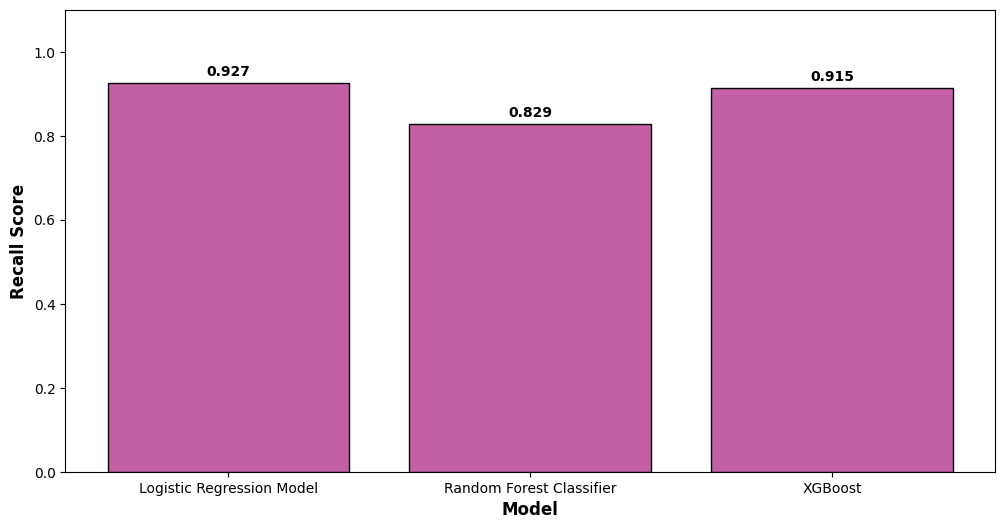

In [29]:
plt.figure(figsize=(12, 6))
categories = ["Logistic Regression Model" , "Random Forest Classifier", "XGBoost"]
scores = [rc1_score, rc2_score, rc3_score]

bars = plt.bar(categories, scores, color="#c460a5", edgecolor="black")

plt.xlabel("Model" , fontsize=12, fontweight="bold")
plt.ylabel("Recall Score" , fontsize=12, fontweight="bold")

plt.bar_label(bars, padding=3, fmt='%.3f', fontweight="bold", fontsize=10)
plt.ylim(0, 1.1)

plt.show()


### Baseline Model Seçimi
Üç model, aynı train/test bölünmesi ve concatenation ile birleştirilmiş fingerprint verisi kullanılarak karşılaştırılmıştır. Model seçiminde kaçırılan bir etkileşimin (False Negative) klinik maliyeti yüksek olduğu için öncelikli kriter Recall olsa da Precision ve ROC-AUC değerleri de göz önünde bulundurulmuştur.

En yüksek Recall (0.93) ve ROC-AUC (0.98) değerlerini Logistic Regression vermiş, XGBoost (Recall: 0.91) ve Random Forest (Recall: 0.83) onu izlemiştir.

Bu sonuç, Morgan Fingerprint temsilinin yüksek boyutlu ve seyrek (sparse) ikili yapısının, ağaç-tabanlı modellerin aradığı karmaşık doğrusal olmayan ilişkilerden çok, doğrusal bir ilişkiye daha yatkın olabileceğini düşündürmektedir. Bu nedenle nihai model olarak Logistic Regression seçilmiştir.

### Yanlış Pozitif Oranı Analizi

In [33]:
y_test_arr = np.array(y_test)
neg_test_indices = np.where(y_test_arr == 0)[0]

probs = model1.predict_proba(x_test[neg_test_indices])[:, 1]

dogru_negatif_oran = (probs < 0.5).mean() * 100
yanlis_pozitif_oran = (probs >= 0.5).mean() * 100

print(f"Test setindeki {len(neg_test_indices)} 'etkileşim yok' örneğinden:")
print(f"  → Modelin doğru tahmin ettiği (düşük risk dediği): %{dogru_negatif_oran:.1f}")
print(f"  → Modelin yanlış tahmin ettiği (yüksek risk dediği): %{yanlis_pozitif_oran:.1f}")

Test setindeki 39949 'etkileşim yok' örneğinden:
  → Modelin doğru tahmin ettiği (düşük risk dediği): %91.5
  → Modelin yanlış tahmin ettiği (yüksek risk dediği): %8.5


Modelin recall/precision metrikleri genel performansı gösterse de, etkileşim olmayan ilaç çiftlerinde ne sıklıkla yanlış alarm verdiğini ayrıca incelemek önemlidir.

Model, negatif örneklerin %91.5'ini doğru sınıflandırırken %8.5 oranında yanlış pozitif üretmektedir. Bu, klinik false-negative maliyetinin false-positive'ten yüksek kabul edildiği recall-öncelikli tasarım tercihiyle tutarlıdır.

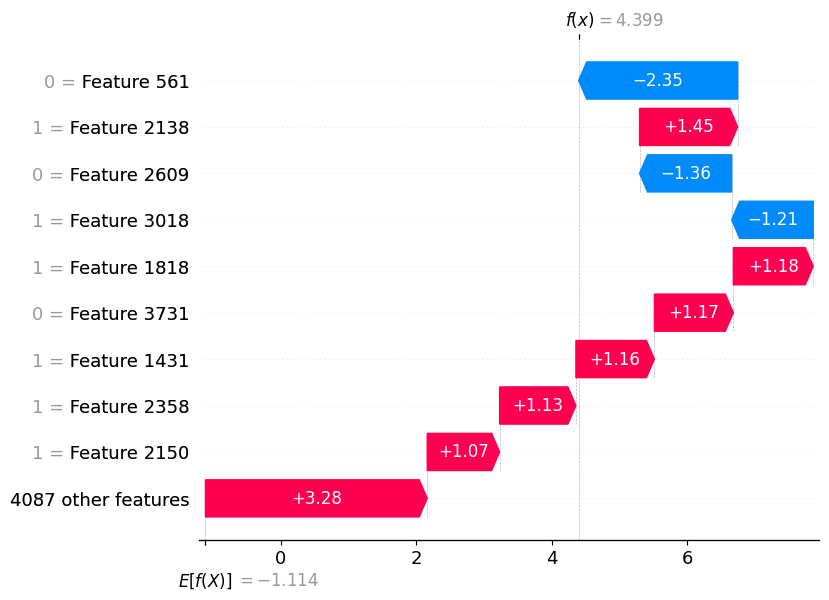

In [30]:
import shap
background = shap.sample(x_train, 100, random_state=42)

explainer = shap.LinearExplainer(model1, background, link=shap.links.logit)

x_test_sample = x_test[:50]
shap_values = explainer(x_test_sample)

shap.plots.waterfall(shap_values[1])

## SHAP ile Model Yorumlanabilirliği

Model %93 Recall ile başarılı tahminler üretse de, hangi girdiye dayanarak bu kararı verdiğini açıklamak için SHAP kullanıyoruz. (SHapley Additive exPlanations)

Modelin her tahminini, girdideki hangi özelliklerin ne yönde ve ne kadar etkili
olduğunu göstererek açıklıyor. Bu, klinik karar destek bağlamında önemlidir bir model sadece "risk var" demekle kalmayıp, bu kararın gerekçesini de sunabilmelidir.

Yukarıdaki waterfall grafiği, rastgele seçilen bir test örneği için modelin kararını adım adım gösteriyor. E[f(X)] = -0.998, modelin tüm veri seti genelindeki ortalama tahminini (referans noktası) gösterir. Bu spesifik örnek için model f(x) = 4.385 skorunu üretmiştir. Ortalamanın belirgin şekilde üzerinde, yani model bu çiftin etkileşme olasılığını güçlü şekilde desteklemektedir. Birkaç azaltıcı özelliğe rağmen, çok sayıda küçük pozitif katkının toplamda baskın gelmesi, modeli bu çifti yüksek riskli olarak sınıflandırmaya yöneltmiştir.

Bu ilaç çiftinde, Feature 561'in yokluğu (0 = Feature 561) tek başına en güçlü negatif etkiyi yapmış (-2.34) yani bu bit'in olmaması, riski bir miktar azaltıyor. Ama buna rağmen, 8 farklı bit'in varlığı ve özellikle 4087 diğer özelliğin toplam etkisi (+3.01) bu tek negatif etkiyi fazlasıyla bastırmış. Sonuç olarak model, ortalamanın (-0.998) çok üzerinde, 4.385'lik yüksek bir risk skoru üretmiş yani bu iki ilacın etkileşme olasılığını güçlü şekilde destekliyor.


## Sonraki Adımlar

Bu modelin Streamlit üzerinden dağıtımı VSCode üzerinde gerçekleştirilecektir.

In [31]:
import joblib

joblib.dump(model1, 'logistic_model.pkl')

print("Model başarıyla .pkl formatında kaydedildi.")

Model başarıyla .pkl formatında kaydedildi.
